# 05.22 - Time-Series Splitting & Validation

**Phase:** 05 - Machine Learning

**Status:** VERIFIED

---

## 1. What Are We Solving?

Standard random train/test split does not work for time series -- it uses future data to predict the past (data leakage).

## 2. Why Does This Matter?

Time series is everywhere: stock prices, weather, sales forecasting. Using the wrong split gives overly optimistic results.

## 3. Prerequisites

- 05.15: Cross-validation

## 4. Learning Objectives

- Understand why random splits fail for time series
- Implement time-series aware splitting
- Use TimeSeriesSplit from sklearn

## 5. Mental Model

Time series: data is ordered by time.
Rule: never use future data to predict the past.
Train on past, validate on future. Slide forward.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## 6. Why Random Splits Fail

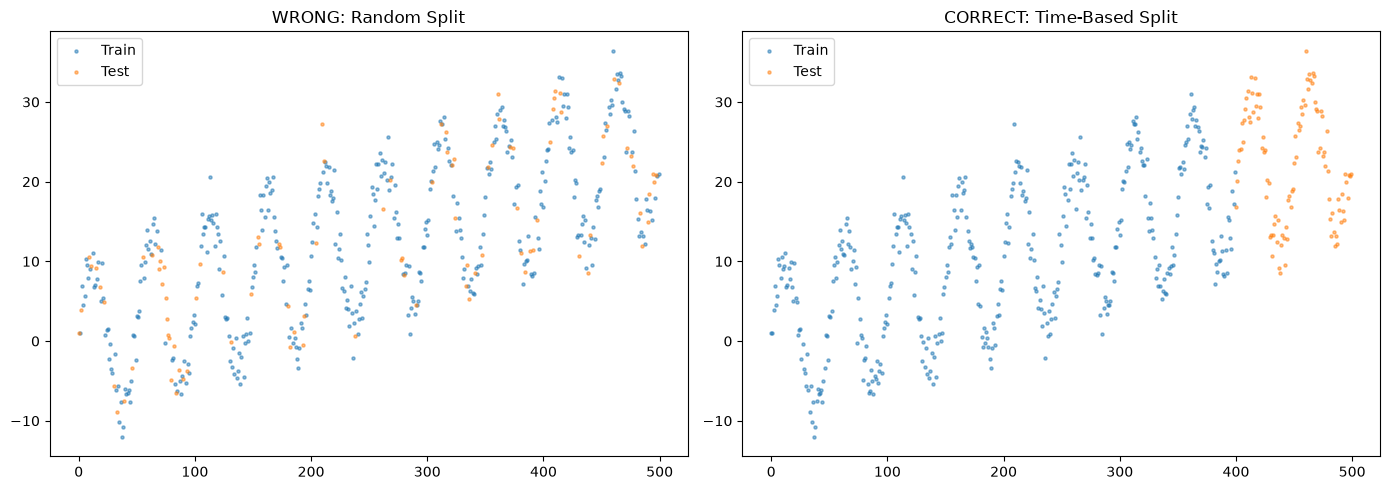

In [2]:
np.random.seed(42)
n = 500
time = np.arange(n)
y = 0.05 * time + 10 * np.sin(2 * np.pi * time / 50) + np.random.randn(n) * 2
X = time.reshape(-1, 1)

# CORRECT: Time-based split
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random split
from sklearn.model_selection import train_test_split
X_r, X_t, y_r, y_t = train_test_split(X, y, test_size=0.2, random_state=42)
axes[0].scatter(X_r, y_r, s=5, alpha=0.5, label="Train")
axes[0].scatter(X_t, y_t, s=5, alpha=0.5, label="Test")
axes[0].set_title("WRONG: Random Split")
axes[0].legend()

# Time split
axes[1].scatter(X_train, y_train, s=5, alpha=0.5, label="Train")
axes[1].scatter(X_test, y_test, s=5, alpha=0.5, label="Test")
axes[1].set_title("CORRECT: Time-Based Split")
axes[1].legend()

plt.tight_layout()
plt.savefig("timeseries_split.png", dpi=100, bbox_inches="tight")
plt.show()

## 7. TimeSeriesSplit from sklearn

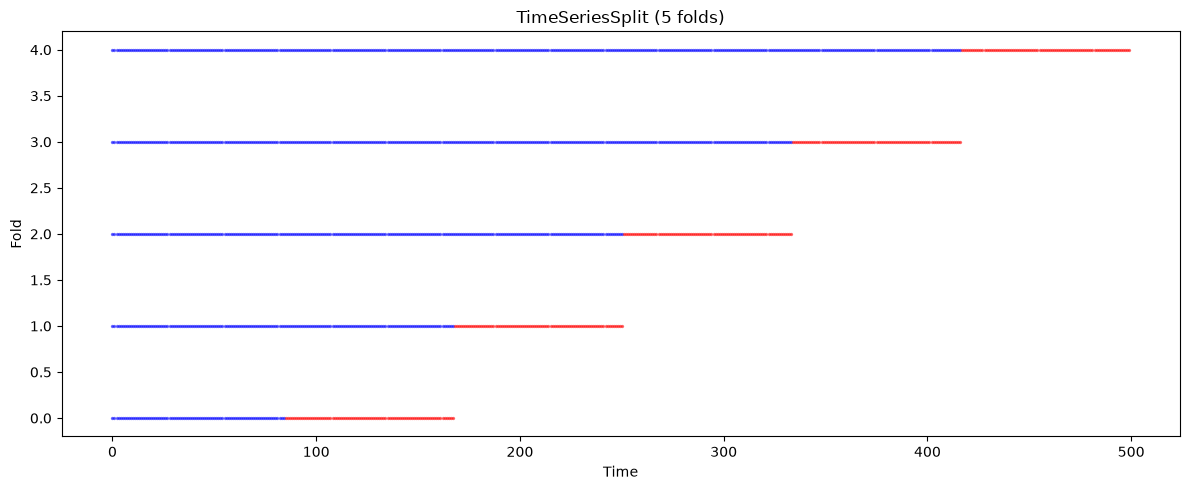

In [3]:
tscv = TimeSeriesSplit(n_splits=5)

fig, ax = plt.subplots(figsize=(12, 5))
for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    ax.scatter(X[train_idx], [i]*len(train_idx), c="blue", s=2, alpha=0.5)
    ax.scatter(X[test_idx], [i]*len(test_idx), c="red", s=2, alpha=0.5)
ax.set_xlabel("Time")
ax.set_ylabel("Fold")
ax.set_title("TimeSeriesSplit (5 folds)")
plt.tight_layout()
plt.savefig("timeseries_cv.png", dpi=100, bbox_inches="tight")
plt.show()

In [4]:
lr = LinearRegression()
tscv = TimeSeriesSplit(n_splits=5)

scores = cross_val_score(lr, X, y, cv=tscv, scoring="neg_mean_squared_error")
print("Time Series CV RMSE: " + str(round(np.sqrt(-scores).mean(), 2)))

scores_random = cross_val_score(lr, X, y, cv=5, scoring="neg_mean_squared_error")
print("Random CV RMSE (WRONG): " + str(round(np.sqrt(-scores_random).mean(), 2)))

Time Series CV RMSE: 7.94
Random CV RMSE (WRONG): 7.54


## 8. Feature Engineering for Time Series

In [5]:
df = pd.DataFrame({"time": time, "y": y})
df["lag_1"] = df["y"].shift(1)
df["lag_2"] = df["y"].shift(2)
df["rolling_mean_7"] = df["y"].rolling(7).mean()
df["rolling_std_7"] = df["y"].rolling(7).std()
df = df.dropna()
print("Features created: " + str(list(df.columns)))

Features created: ['time', 'y', 'lag_1', 'lag_2', 'rolling_mean_7', 'rolling_std_7']


## 9. Common Mistakes

1. Random splitting time series
2. Using future features
3. Ignoring seasonality
4. Ignoring non-stationarity

## 10. Coding Exercises

### Exercise 1: Stock Prediction
Create synthetic stock data. Build features and predict.

### Exercise 2: Rolling Forecast
Implement rolling window forecast.

In [6]:
# EXERCISE 1: Stock-like time series
print("Exercise: Build a time-series forecasting pipeline.")

Exercise: Build a time-series forecasting pipeline.


In [7]:
# EXERCISE 2: Rolling forecast
print("Exercise: Implement rolling window forecasting.")

Exercise: Implement rolling window forecasting.


## 11. Closed-Book Recall

1. Why do random splits fail for time series?
2. What is TimeSeriesSplit?
3. What are lag features?

## 12. Teach-Back Questions

Explain temporal splitting. How lag features work. When to use differencing.

## 13. Summary

Time series requires temporal splitting. TimeSeriesSplit provides expanding window CV. Lag features and rolling statistics help models learn temporal patterns.

## 14. Further Experiment

1. Try ARIMA vs ML for forecasting.
2. Add seasonal features.
3. Research Prophet library.

## Verification Status
```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: [numpy, pandas, matplotlib, scikit-learn]
OUTPUTS: PASS
LAST VERIFIED: 2026-08-30
```